# Hölder weights as a continuous bound-design variable

Weighted mini-bucket elimination replaces the discrete sum/max choice by a continuum of weighted power sums. This notebook isolates one split bucket so that the generalized Hölder inequality and the role of the weights can be inspected directly.

In [1]:
CHAPTER_DIR = "ch07"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## A split bucket

For positive functions $f_1,f_2$, the exact contraction is $\sum_x f_1(x)f_2(x)$. For weights $w$ and $1-w$, Hölder gives

$$
\sum_x f_1(x)f_2(x)
\leq
\left(\sum_x f_1(x)^{1/w}\right)^w
\left(\sum_x f_2(x)^{1/(1-w)}\right)^{1-w}.
$$

exact 8.434149430193761 best bound 10.105732062052446 optimal w 0.51


Saved: figs/ch07_02_holder_weight_optimization.pdf


Saved: figs/ch07_02_holder_weight_optimization.png


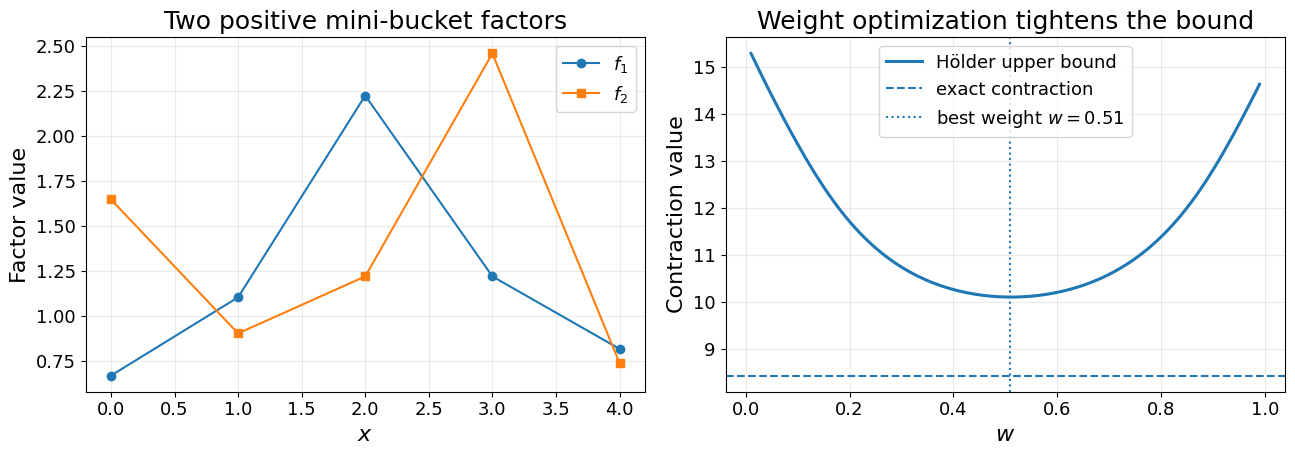

In [2]:
x=np.arange(5)
f1=np.exp(np.array([-.4,.1,.8,.2,-.2])); f2=np.exp(np.array([.5,-.1,.2,.9,-.3]))
exact=np.sum(f1*f2)
def psum(f,w):
    if w<1e-10: return np.max(f)
    return np.sum(f**(1/w))**w
ws=np.linspace(.01,.99,197)
bounds=np.array([psum(f1,w)*psum(f2,1-w) for w in ws])
wstar=ws[np.argmin(bounds)]
print('exact',exact,'best bound',bounds.min(),'optimal w',wstar)
assert np.all(bounds>=exact-1e-10)
fig,axes=plt.subplots(1,2,figsize=(13.2,4.8))
axes[0].plot(x,f1,marker='o',label='$f_1$'); axes[0].plot(x,f2,marker='s',label='$f_2$'); axes[0].set_xlabel('$x$'); axes[0].set_ylabel('Factor value'); axes[0].set_title('Two positive mini-bucket factors'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(ws,bounds,linewidth=2.2,label='Hölder upper bound'); axes[1].axhline(exact,linestyle='--',label='exact contraction'); axes[1].axvline(wstar,linestyle=':',label=f'best weight $w={wstar:.2f}$'); axes[1].set_xlabel('$w$'); axes[1].set_ylabel('Contraction value'); axes[1].set_title('Weight optimization tightens the bound'); axes[1].legend(); axes[1].grid(alpha=.25)
fig.tight_layout(); save_figure(fig,'ch07_02_holder_weight_optimization'); plt.show()

## Limiting cases

As a weight approaches zero, its weighted power sum approaches a maximum. This recovers the sum/max form of ordinary mini-bucket elimination.

In [3]:
table=[]
for w in [.5,.2,.05,.01,1e-12]: table.append((w,psum(f1,w),psum(f2,1-w),psum(f1,w)*psum(f2,1-w)))
display(pd.DataFrame(table,columns=['w','factor 1 aggregate','factor 2 aggregate','bound']))

,w,factor 1 aggregate,factor 2 aggregate,bound
0,5.000000e-01,2.964103,3.409882,10.107243
1,2.000000e-01,2.263900,5.173411,11.712084
2,5.000000e-02,2.225542,6.467514,14.393723
3,1.000000e-02,2.225541,6.870451,15.290469
4,1.000000e-12,2.225541,6.975383,15.524000


## Exercises

1. Derive the first-order condition for the optimal weight.
2. Rescale either factor by a positive constant and explain why the relative gap is unchanged.
3. Extend the experiment to three mini-buckets and optimize weights on the simplex.